In [ ]:
import numpy as np

W, H = 500, 500
# Create 1D coordinate arrays
x = np.linspace(-20, 20, W)
y = np.linspace(-20, 20, H)
X, Y = np.meshgrid(x, y)



In [80]:
import numpy as np
from scipy.special import expit
def sigmoid(x, k=1.0):
    """
    Vectorized Sigmoid with adjustable slope k.
    x: NumPy array of any shape e.g. (500, 500)
    k: Steepness factor (float)
    """
    return expit(k * x)
def _get_2dsig(w,XY,k=1):
    w_nonlin = sigmoid(np.einsum('ijk,k->ij',XY,w),k=k)
    return w_nonlin
def get_dom(w1,w2,X,Y,k=1):
    XY = np.stack((X,Y),axis=-1)
    w1_nonlin = _get_2dsig(w1,XY,k=k)
    w2_nonlin = _get_2dsig(w2,XY,k=k)
    w12_nonlin = np.stack((w1_nonlin,w2_nonlin),axis=-1)
    dom = w12_nonlin.min(axis=2)
    return dom
def get_vordom(X,Y,k=1,is_inverse=False):
    thts = np.array([0,1,2])*np.pi*(2/3)
    if is_inverse:
        thts = - thts
    coss = np.cos(thts)
    sins = np.sin(thts)
    ws = np.stack((coss,sins),axis = 1)
    doms = []
    for ind,jnd in zip([0,1,2],[1,2,0]):
        doms.append(get_dom(ws[ind],-ws[jnd],X,Y,k=k))
    doms = foo = np.stack(doms,axis=2)
    return doms
def get_DWdom(tht,X,Y,k=1):
    XY = np.stack((X,Y),axis=-1)
    w = np.array((np.cos(tht),np.sin(tht)))
    dom = _get_2dsig(w,XY,k=k)
    doms = np.stack((dom,-dom),axis = 2)
    return doms




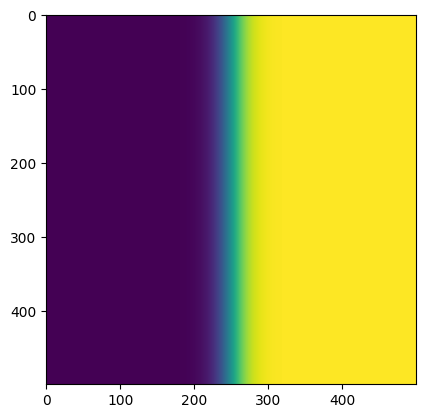

In [82]:
doms = get_DWdom(0,X,Y,k=1)
plt.imshow(doms[:,:,0])

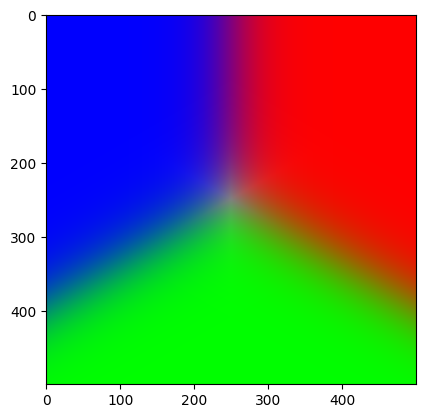

In [78]:
doms =get_vordom(X,Y,k=.5,is_inverse=False)
plt.imshow(doms)

In [54]:
thts = np.array([0,1,2])*np.pi*(2/3)    
coss = np.cos(thts)
sins = np.sin(thts)
np.stack((coss,sins),axis = 1)

array([[ 1.       ,  0.       ],
       [-0.5      ,  0.8660254],
       [-0.5      , -0.8660254]])

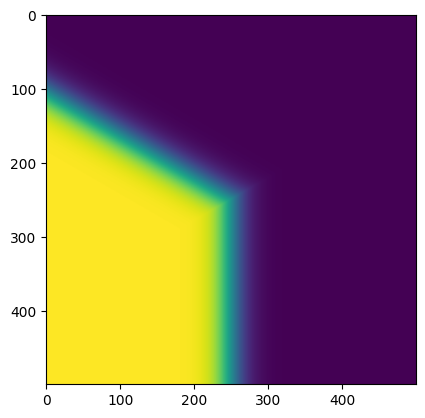

In [ ]:
w1 = np.array([-1,0])
w2 = np.array([np.cos(np.pi*(2/3)),np.sin(np.pi*(2/3))])
dom = get_dom(w1,w2,X,Y,k=1)





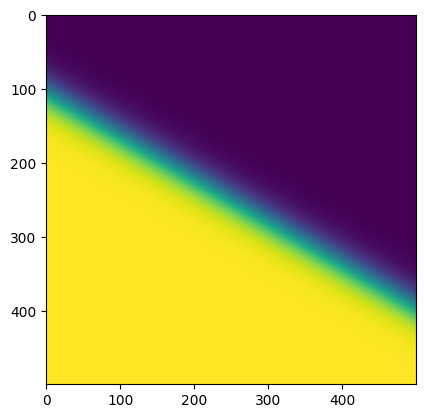

In [45]:
plt.imshow(sigmoid(w2_lin,k=1))
w2_nonlin = sigmoid(w2_lin,k=1)
w1_nonlin =  sigmoid(np.einsum('ijk,k->ij',XY,w1),k=1)

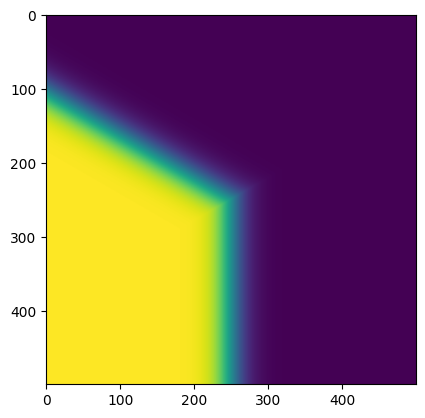

In [46]:
w12_nonlin = np.stack((w1_nonlin,w2_nonlin),axis=-1)
plt.imshow(w12_nonlin.min(axis=2))